In [1]:
import sys
import itertools
sys.path.append('../')
import random
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb #baseline
from utils import *
from baselines import *

In [ ]:
train_size = 100 #set train size here!! Make sure not to overwrite a saved experiment!!!!
d_list = [2,4,6]
seed_list = [14,15,16,17,18]

In [3]:
def gaussian_noise(n_samples, signal_y, snr=3.0, random_seed = None):
    """
    Generate Gaussian noise with variance scaled to achieve the desired SNR
    relative to the variance of signal_y.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    signal_var = np.var(signal_y)
    target_noise_var = signal_var / snr
    noise = np.random.normal(0, 1, size=n_samples)
    noise_std = np.std(noise)
    noise *= np.sqrt(target_noise_var) / noise_std
    return noise


def slash_noise(n_samples, signal_y, snr=3.0, random_seed = None):
    """
    Generate Slash-distributed noise (Z/U) scaled to achieve desired SNR.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    signal_var = np.var(signal_y)
    target_noise_var = signal_var / snr

    u = np.random.normal(0, 1, size=n_samples)
    v = np.random.uniform(0.001, 1, size=n_samples)
    #v = np.where(v < 1e-6, 1e-6, v)  # prevent divide-by-zero
    raw_noise = u / v

    # Scale to achieve target variance
    noise_std = np.std(raw_noise)
    scaled_noise = raw_noise * np.sqrt(target_noise_var) / noise_std
    return scaled_noise




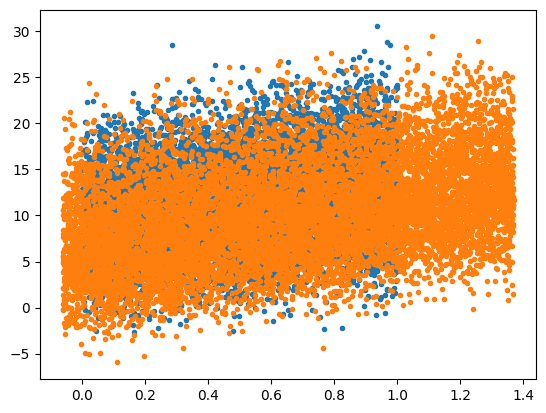

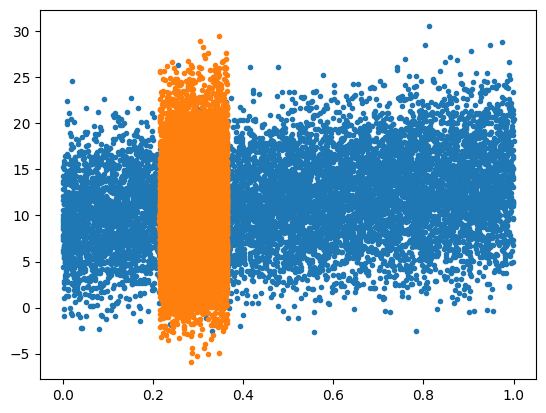

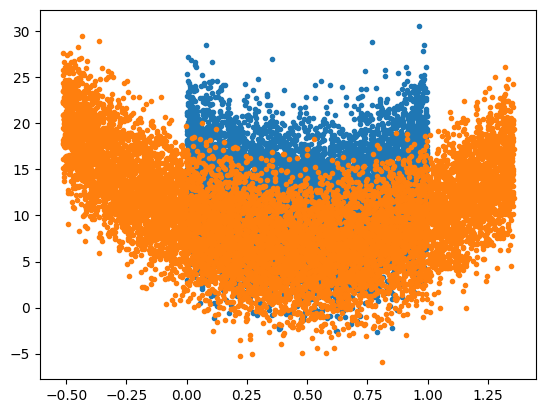

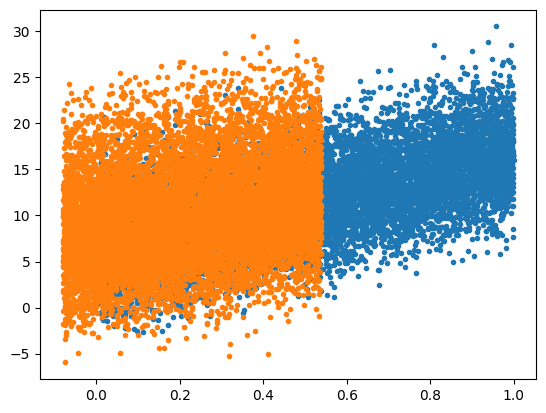

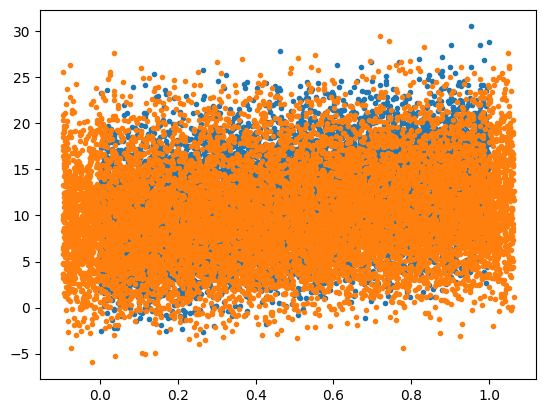

In [4]:
def friedman1(n_samples, add_noise=False, noise_distribution='slash', n_features=5, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    x0 = np.random.uniform(0,1,size=n_samples)
    x1 = np.random.uniform(0,1,size=n_samples)
    x2 = np.random.uniform(0,1,size=n_samples)
    x3 = np.random.uniform(0,1,size=n_samples)
    x4 = np.random.uniform(0,1,size=n_samples)
    X = np.column_stack((x0, x1, x2, x3, x4)) 
    y = 10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4

    if add_noise:
        if noise_distribution == 'gaussian':
            if random_seed is not None:
                eps = gaussian_noise(n_samples, y, random_seed = random_seed)
            else:
                eps = gaussian_noise(n_samples, y)
            y += eps
        elif noise_distribution == 'slash':
            if random_seed is not None:
                eps = slash_noise(n_samples, y, random_seed = random_seed)
            else:
                eps = slash_noise(n_samples, y)
            
            y += eps
        else:
            raise Exception("No valid distribution, only gaussian or slash are accepted")

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y


def friedman1_altered(n_samples, add_noise=False, noise_distribution='slash', n_features=5,
                      d = 1.0,
                      shift_seed=None, random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)
    
    #generate distrubance factors
    a = np.random.normal(1, 0.1*d, size = 4)
    a0, a1, a2, a3 = a
    b = np.random.normal(1, 0.1*d, size = 5)
    b0, b1, b2, b3, b4 = b
    c = np.random.normal(0, 0.05*d, size = 5)
    c0, c1, c2, c3, c4 = c
    #

    #feature scaling
    x0 = np.random.uniform(0,1,size=n_samples) * b0 + c0
    x1 = np.random.uniform(0,1,size=n_samples) * b1 + c1
    x2 = np.random.uniform(0,1,size=n_samples) * b2 + c2
    x3 = np.random.uniform(0,1,size=n_samples) * b3 + c3
    x4 = np.random.uniform(0,1,size=n_samples) * b4 + c4
    

    X = np.column_stack((x0, x1, x2, x3, x4))
    #lable scaling
    y = a0*10*np.sin(x0*x1) + a1*20*(x2 - 0.5)**2 + a2*10*x3 + a3*5*x4

    if add_noise:
        if noise_distribution == 'gaussian':
            eps = gaussian_noise(n_samples, y)
            y += eps
        elif noise_distribution == 'slash':
            eps = slash_noise(n_samples, y)
            y += eps
        else:
            raise Exception("No valid distribution, only gaussian or slash are accepted")

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y



#Check that random seed works!
X, y = friedman1(10000, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed = 1)
X_altered, y_altered= friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                   n_features=10, d = 5, shift_seed=1, random_seed = 1) 

plt.plot(X[:,0], y, '.')
plt.plot(X_altered[:,0], y_altered, '.')
plt.show()

plt.plot(X[:,1], y, '.')
plt.plot(X_altered[:,1], y_altered, '.')
plt.show()

plt.plot(X[:,2], y, '.')
plt.plot(X_altered[:,2], y_altered, '.')
plt.show()

plt.plot(X[:,3], y, '.')
plt.plot(X_altered[:,3], y_altered, '.')
plt.show()

plt.plot(X[:,4], y, '.')
plt.plot(X_altered[:,4], y_altered, '.')
plt.show()







In [5]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_normal_normal = pd.DataFrame(columns = ['seed', 'd', 'method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0', 'rmse', 'mae'])
v_list = [0.05]
source_tree_size_list = [1]
target_tree_size_list = [1]
k_list = [0.01, 0.05]
m_0_list = [0.5]


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    k_list,
    m_0_list
))

# --- Step 3: Sample random combinations ---
random.seed(42)  # FIXED seed for reproducibility across methods
n_samples = 50   # or whatever budget you choose
#sampled_configs = random.sample(param_grid, n_samples)

for seed in seed_list:
    
    X_target_test, y_target_test = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(train_size, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    for d in d_list:
        X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, d=d, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
        for config in param_grid:
            v, source_tree_size, target_tree_size, k, m_0 = config


            #Test for all methods!!!!

            method = f'LSTransferTreeBoost'
            fiter = LSTransferTreeBoost(epochs=1000, v=v, source_tree_size=source_tree_size, 
                                    target_tree_size=target_tree_size, alpha_0=1.0, k=k, m_0=m_0)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves=False)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, d, method, v, source_tree_size, target_tree_size, k, m_0, rmse, mae]
            ablation_transfer_normal_normal.to_csv(f'results/LSTransferTreeBoost_ablation_{train_size}.csv')





                            
        



In [6]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_normal_normal = pd.DataFrame(columns = ['seed', 'method', 'd',
                                   'v', 'target_tree_size', 'rmse', 'mae'])

v_list = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.12, 0.15]
target_tree_size_list = [1,2,3,4,5,6,7]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    target_tree_size_list
))



for seed in seed_list:
    X_target_test, y_target_test = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(train_size, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    for d in d_list:
       
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, d=d, 
                                                        shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
        for config in param_grid:
            v, target_tree_size = config


            method = 'xgboost'
            params = {
                'objective': 'reg:squarederror',  # Regression with squared error
                'max_depth': target_tree_size,                   # Maximum depth of a tree
                'eta': v,                       # Learning rate
                'eval_metric': 'rmse',           # RMSE as evaluation metric
                }
                    
            bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=1000, params=params)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, method, d, v, target_tree_size, rmse,
                               mae]
            
            ablation_transfer_normal_normal.to_csv(f'results/xgboost_ablation_{train_size}.csv')

            method = 'xgboost_naive_transfer'
            params = {
                'objective': 'reg:squarederror',  # Regression with squared error
                'max_depth': target_tree_size,                   # Maximum depth of a tree
                'eta': v,                       # Learning rate
                'eval_metric': 'rmse',           # RMSE as evaluation metric
                }
            X_comb = np.concatenate((X_target_train, X_source_train)) 
            y_comb = np.concatenate((y_target_train, y_source_train))       
            bst = train_xgboost(X_comb, y_comb, X_target_val, y_target_val, boosting_rounds=1000, params=params)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, method, d, v, target_tree_size, rmse,
                               mae]
            
            ablation_transfer_normal_normal.to_csv(f'results/xgboost_ablation_{train_size}.csv')
                            
        



KeyboardInterrupt: 

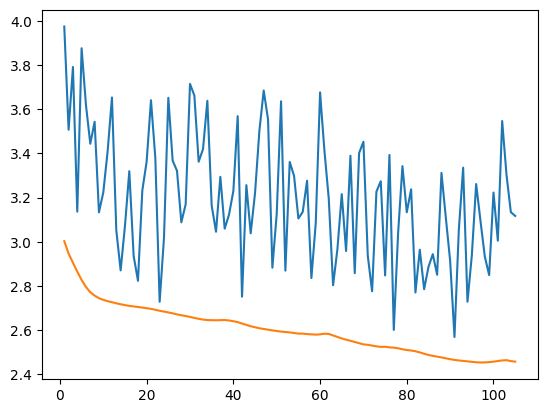

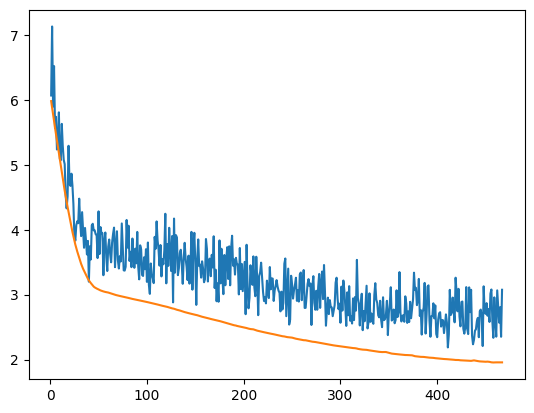

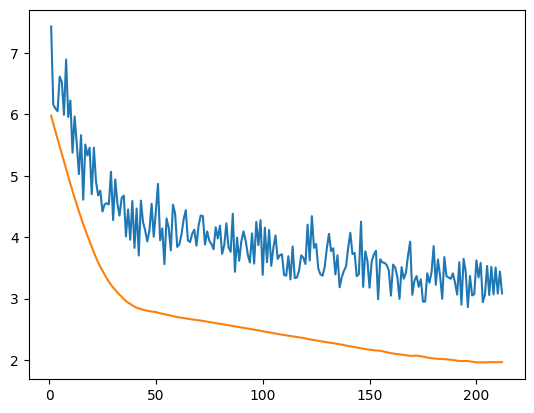

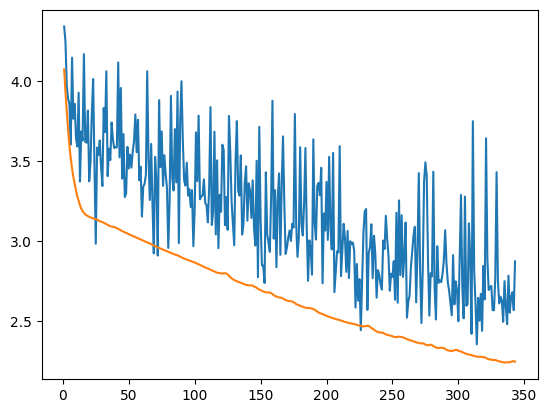

KeyboardInterrupt: 

In [ ]:
#also run mlp finetuning
ablation_transfer_normal_normal = pd.DataFrame(columns = ['seed', 'd', 'method', 'rmse', 'mae'])

for seed in seed_list:
    
    X_target_test, y_target_test = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(train_size, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    for d in d_list:
        X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, d=d, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)


        #Test for all methods!!!!

        method = f'MLP'
        mlp = MLP(10, 100, 100, 100, 1)
        dataloader_train = process_dataset_for_base_network(X_source_train, y_source_train)
        mlp = train_mlp_on_source(dataloader_train, mlp, epochs=100)
        dataloader_train, dataloader_val, dataloader_test = process_datasets_for_finetuning(X_target_train, y_target_train,
                                    X_target_val, y_target_val, X_target_test, y_target_test, batch_size=32)
        
        mlp, train_loss, val_loss = finetune_mlp_on_target(dataloader_train, dataloader_val, mlp, epochs=1000, freeze_layers=None)
        rmse, mae = test_final_mlp(dataloader_test, mlp)
        ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, d, method, rmse, mae]
        ablation_transfer_normal_normal.to_csv(f'results/MLP_ablation_{train_size}.csv')





                            
        



#ablation study for TwostageTradaBoost (currently unused)
ablation_transfer_normal_normal = pd.DataFrame(columns = ['seed', 'method', 'd',
                                   'lr', 'target_tree_size', 'n_boosters', 'rmse', 'mae'])

lr_list = [0.5, 1]
target_tree_size_list = [1,2,3,4]
n_boosters = [10, 50, 100]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    lr_list,
    target_tree_size_list,
    n_boosters
))



for seed in seed_list:
    X_target_test, y_target_test = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(train_size, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    for d in d_list:
       
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, d=d, 
                                                        shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
        for config in param_grid:
            lr, target_tree_size, n_boosters = config


            method = 'trada'
            
                    
            model= train_twostagetradaboostr2(X_source_train, y_source_train, X_target_train, y_target_train, n_estimators=n_boosters, 
                       tree_size_depth=target_tree_size, lr=lr)
            preds = predict_twostagetradaboostr2(X_target_test, model)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, method, d, lr, target_tree_size, n_boosters, rmse,
                               mae]
            
            ablation_transfer_normal_normal.to_csv(f'results/trada_ablation_{train_size}.csv')


                            
        

